In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("DS_Companies.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


# Heatmap

In [4]:
df.corr() # correlation should above 0.5 even its in minus -0.5 its good (its to check impact one column to others cloumn)

ValueError: could not convert string to float: 'MI'

In [13]:
# give error cause is work only on number column

In [14]:
numeric_df=df.select_dtypes(include="int64")

In [15]:
numeric_df.corr()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
Unnamed: 0,1.000000,0.886550,-0.096250,0.167025,0.095000
work_year,0.886550,1.000000,-0.087577,0.170493,0.076314
salary,-0.096250,-0.087577,1.000000,-0.083906,-0.014608
salary_in_usd,0.167025,0.170493,-0.083906,1.000000,0.132122
remote_ratio,0.095000,0.076314,-0.014608,0.132122,1.000000


<Axes: >

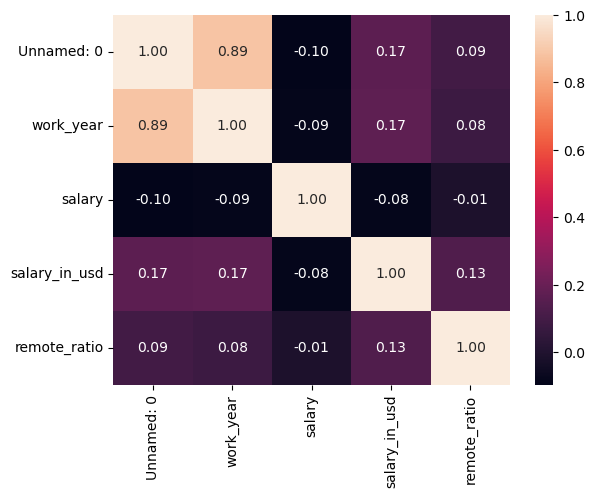

In [16]:
sns.heatmap(data=numeric_df.corr(),annot=True,fmt='.2f',)

In [17]:
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [18]:
# first we go for pandas then seaborn then why pandas is avoided now...

In [19]:
df.isnull().sum() # to check null value

Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [20]:
df.columns

Index(['Unnamed: 0', 'work_year', 'experience_level', 'employment_type',
       'job_title', 'salary', 'salary_currency', 'salary_in_usd',
       'employee_residence', 'remote_ratio', 'company_location',
       'company_size'],
      dtype='object')

In [21]:
df.drop(df[['Unnamed: 0','salary']],axis=1,inplace=True) # drop unnecassary cloumn

In [22]:
df.head()

,work_year,experience_level,employment_type,job_title,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,USD,150000,US,50,US,L


<Axes: xlabel='work_year', ylabel='salary_in_usd'>

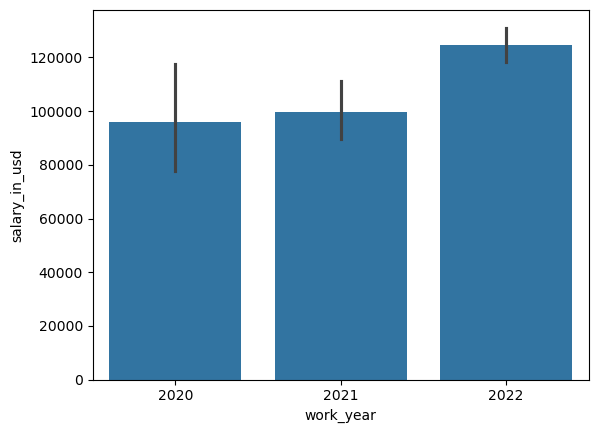

In [23]:
sns.barplot(x="work_year" , y="salary_in_usd",data=df)

In [24]:
df["work_year"].unique()

array([2020, 2021, 2022])

In [25]:
df1=df.groupby("work_year")["salary_in_usd"].mean().round(2)

In [26]:
df1

work_year
2020     95813.00
2021     99853.79
2022    124522.01
Name: salary_in_usd, dtype: float64

In [27]:
df1.index

Index([2020, 2021, 2022], dtype='int64', name='work_year')

In [28]:
df1.values

array([ 95813.  ,  99853.79, 124522.01])

In [29]:
data={
    "work_year":df1.index,
    "average_salary":df1.values
}

In [30]:
df1=pd.DataFrame(data)

In [31]:
df1

,work_year,average_salary
0,2020,95813.00
1,2021,99853.79
2,2022,124522.01


<Axes: xlabel='work_year'>

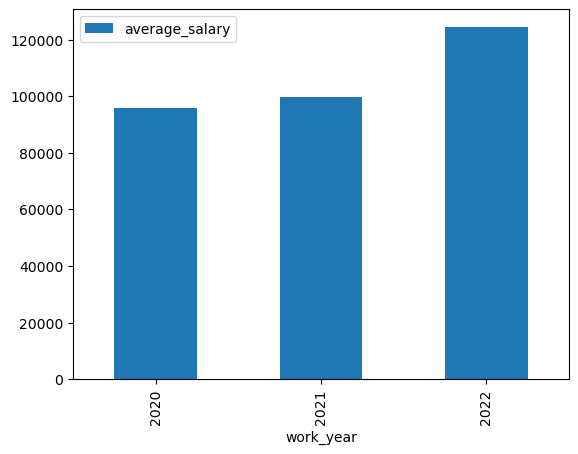

In [32]:
df1.plot(kind="bar",x="work_year",y="average_salary")

In [33]:
df1["average_salary"]=(df1['average_salary']/1000).round(2)

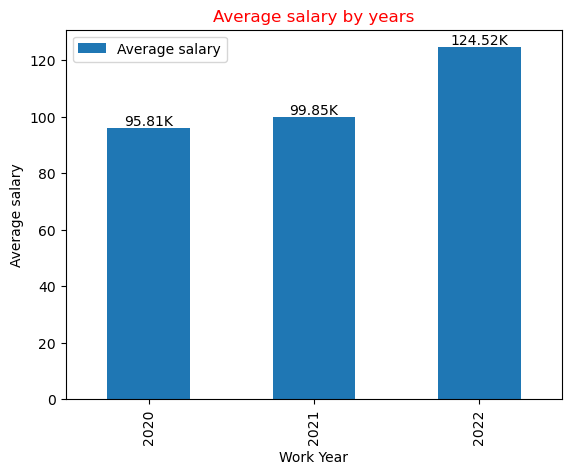

In [34]:
ax = df1.plot(kind="bar", x="work_year", y="average_salary", legend=True)
ax.bar_label(ax.containers[0],labels=df1['average_salary'].map('{:.2f}K'.format))
ax.legend(["Average salary"],loc="upper left")
plt.xlabel("Work Year")
plt.ylabel('Average salary')
plt.title("Average salary by years",color="red")
plt.show()

In [35]:
# now mathplot

In [36]:
df.remote_ratio.unique()

array([  0,  50, 100])

In [37]:
df2=df.remote_ratio.value_counts()

In [38]:
values=df2.to_list()

In [39]:
values

[381, 127, 99]

In [40]:
lables=["Fully remote","no remote","partially work"]

In [41]:
lables

['Fully remote', 'no remote', 'partially work']

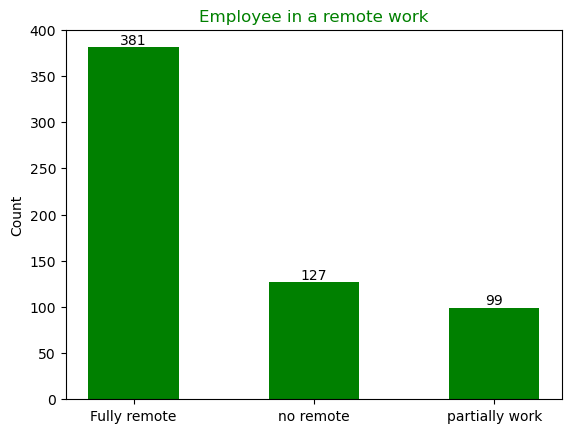

In [45]:
z=plt.bar(lables,values,width=0.5,color="green")
plt.bar_label(z)
plt.ylabel('Count')
plt.title("Employee in a remote work",color="green")
plt.show()

# fully remote work are more then other

In [46]:
df.company_size.unique()

array(['L', 'S', 'M'], dtype=object)

In [47]:
df3=df.company_size.value_counts()

In [48]:
df3

company_size
M    326
L    198
S     83
Name: count, dtype: int64

In [49]:
df3.index.to_list()

['M', 'L', 'S']

In [50]:
values2=df3.to_list()

In [51]:
values2

[326, 198, 83]

In [52]:
lable_for_company=["Medium","Large","Small"]
lable_for_company

['Medium', 'Large', 'Small']

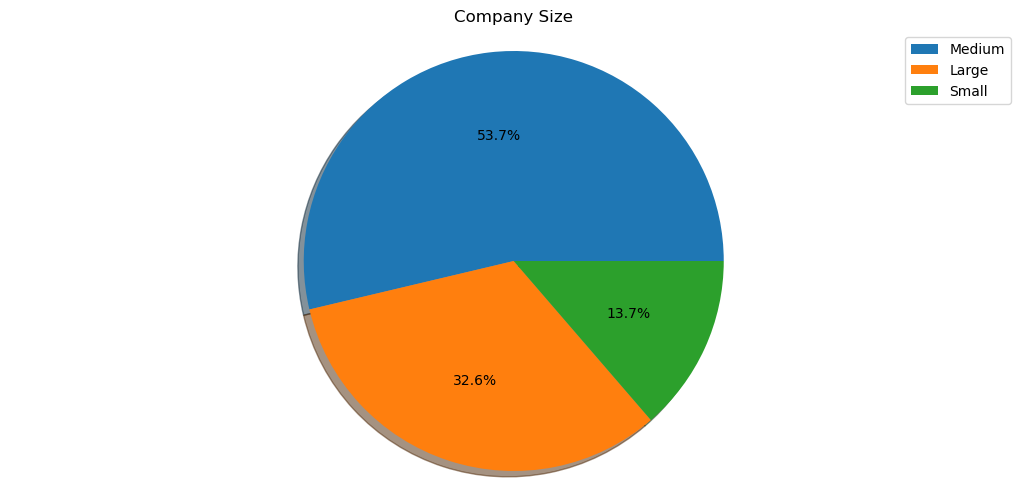

In [53]:
plt.figure(figsize=(13,6)) # 13x6 size
plt.pie(x= values2,labels=None,autopct='%1.1f%%',shadow=True) # autopct for %
plt.legend(labels=lable_for_company,loc='upper right') # loc give location like where to place 
plt.axis("equal") # equal to make equal from all side 
plt.title("Company Size")
plt.show()

In [54]:
df4=df.job_title.value_counts().head()

In [55]:
df4

job_title
Data Scientist               143
Data Engineer                132
Data Analyst                  97
Machine Learning Engineer     41
Research Scientist            16
Name: count, dtype: int64

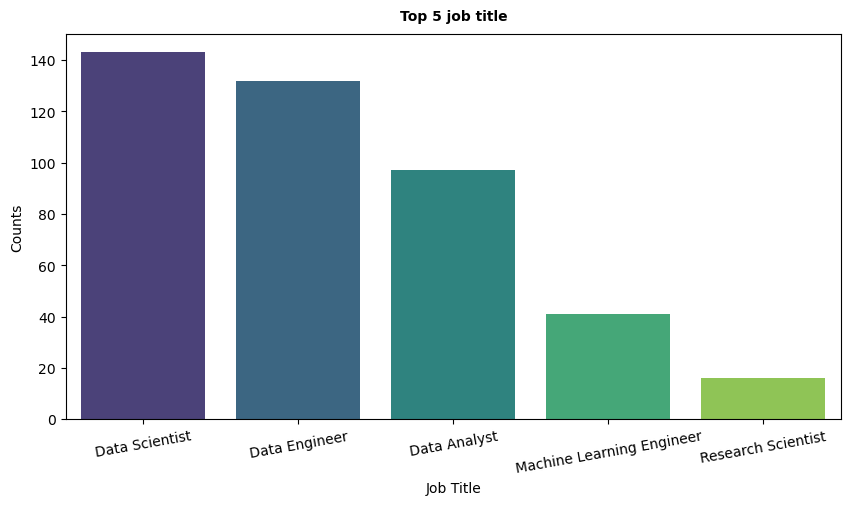

In [56]:
plt.figure(figsize=(10,5))
sns.barplot(x=df4.index,y=df4.values,palette="viridis")
plt.title("Top 5 job title",fontweight="bold",fontsize=10,pad=10)
plt.xlabel("Job Title")
plt.ylabel("Counts")
plt.xticks(rotation=10)
plt.show()

In [57]:
df.head(2)

,work_year,experience_level,employment_type,job_title,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,USD,260000,JP,0,JP,S


In [58]:
df5=df[["salary_in_usd","company_size"]]

In [84]:
df5

,salary_in_usd,company_size
0,79833,L
1,260000,S
2,109024,M
3,20000,S
4,150000,L
...,...,...
602,154000,M
603,126000,M
604,129000,M
605,150000,M


In [59]:
df5[df5['company_size'] == 'S']

,salary_in_usd,company_size
1,260000,S
3,20000,S
6,190000,S
9,125000,S
10,51321,S
...,...,...
510,150000,S
512,65000,S
513,71444,S
515,48000,S


In [60]:
S = df5[df5['company_size'] == 'S']
M = df5[df5['company_size'] == 'M']
L = df5[df5['company_size'] == "L"]

labels = ['Small','Medium', 'Large']
sal_mean = [S['salary_in_usd'].mean(), M["salary_in_usd"].mean(), L["salary_in_usd"].mean()]
sal_mean

[np.float64(77632.67469879518),
 np.float64(116905.46625766871),
 np.float64(119242.99494949495)]

In [62]:
label_change = np.round([x for x in sal_mean], 1) #list comprehension
label_change = list(map(str, label_change))
label_change = [x + '$' for x in label_change]
label_change # to round off and for $ sign



['77632.7$', '116905.5$', '119243.0$']

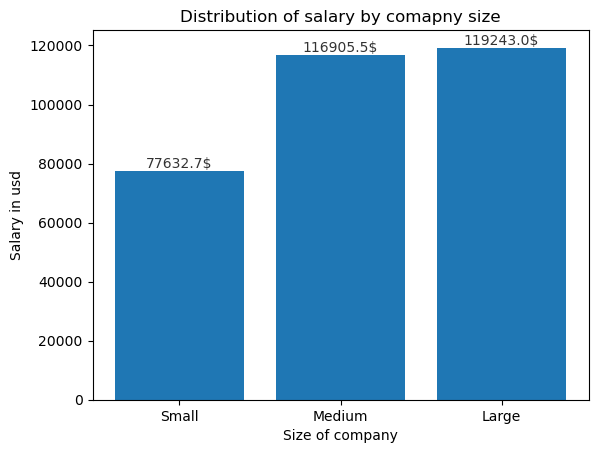

In [63]:
z = plt.bar(labels, sal_mean)
plt.bar_label(z,label_change, alpha = 0.8)
plt.title('Distribution of salary by comapny size')
plt.xlabel('Size of company')
plt.ylabel('Salary in usd')
plt.show()

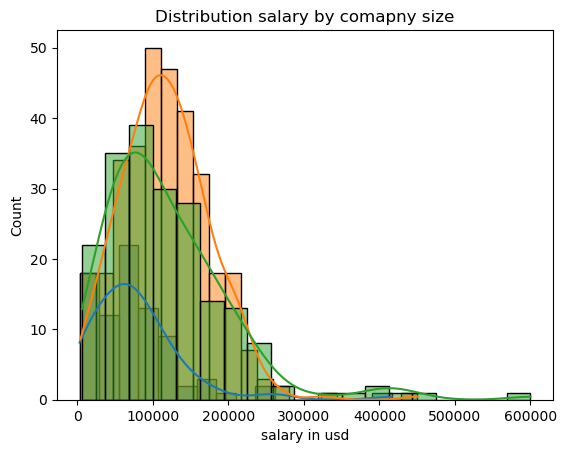

In [64]:
sns.histplot(S['salary_in_usd'], label = 'Small', kde = True)
sns.histplot(M['salary_in_usd'], label = 'Medium', kde = True)
sns.histplot(L['salary_in_usd'], label = 'Large', kde = True)
plt.title('Distribution salary by comapny size')
plt.xlabel('salary in usd')
plt.show()

**Large companies offer the highest salaries, followed by medium and then small companies**